In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

import lightning as L
from torch.utils.data import DataLoader, TensorDataset
from lightning.pytorch.tuner import Tuner

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('10years_SPX_IVS.csv')
df

,Dates,30DAY_IMPVOL_80%MNY_DF,30DAY_IMPVOL_90.0%MNY_DF,30DAY_IMPVOL_95.0%MNY_DF,30DAY_IMPVOL_97.5%MNY_DF,30DAY_IMPVOL_100.0%MNY_DF,30DAY_IMPVOL_102.5%MNY_DF,30DAY_IMPVOL_105.0%MNY_DF,30DAY_IMPVOL_110.0%MNY_DF,30DAY_IMPVOL_120%MNY_DF,...,18MTH_IMPVOL_120%MNY_DF,24MTH_IMPVOL_80%MNY_DF,24MTH_IMPVOL_90.0%MNY_DF,24MTH_IMPVOL_95.0%MNY_DF,24MTH_IMPVOL_97.5%MNY_DF,24MTH_IMPVOL_100.0%MNY_DF,24MTH_IMPVOL_102.5%MNY_DF,24MTH_IMPVOL_105.0%MNY_DF,24MTH_IMPVOL_110.0%MNY_DF,24MTH_IMPVOL_120%MNY_DF
0,4/1/2016,31.4422,20.4818,15.7749,13.5518,11.1926,8.7991,8.6680,12.3428,13.0078,...,11.8507,22.6374,20.1359,18.9134,18.3122,17.6810,17.0812,16.4947,15.3507,13.3202
1,4/4/2016,32.3816,21.0527,16.4633,14.4232,12.1854,9.7695,9.1445,12.4163,13.2117,...,12.0997,22.8203,20.3300,19.1046,18.4937,17.8915,17.2888,16.7016,15.5572,13.5400
2,4/5/2016,32.8637,22.0677,17.6430,15.6324,13.4519,11.2138,9.7895,12.3206,12.3206,...,12.5537,23.2521,20.7511,19.5040,18.8611,18.3484,17.7543,17.1416,15.9772,13.9185
3,4/6/2016,32.3115,20.9377,16.4275,14.4957,12.2162,9.9239,8.8714,11.5959,11.5959,...,12.2230,22.9935,20.4688,19.2367,18.6073,18.0355,17.4445,16.8486,15.6908,13.6485
4,4/7/2016,33.5882,22.9630,18.5421,16.4382,14.1363,11.4923,9.7613,11.6225,11.7970,...,12.8713,23.5757,21.0630,19.8167,19.1972,18.6367,18.0572,17.4823,16.3173,14.2314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2642,5/19/2026,36.3007,24.9829,20.1980,17.9325,15.3420,13.4098,12.3552,12.9116,19.7180,...,14.5225,24.6998,22.3562,21.1966,20.6092,18.9822,18.4450,17.9264,16.9253,15.2512
2643,5/20/2026,35.9650,24.5599,19.5751,17.2373,15.0037,13.4033,12.5152,13.4071,20.2456,...,14.5506,24.5622,22.2231,21.0593,20.4780,19.3770,18.3458,17.8333,16.8508,15.2362
2644,5/21/2026,36.2621,24.3449,19.1241,16.7278,14.4524,12.9001,12.1053,13.1761,20.5820,...,14.4419,24.4429,22.1017,20.9393,20.3690,18.8140,18.2213,17.7088,16.7347,15.1386
2645,5/22/2026,36.9736,24.5802,19.2580,16.8579,14.5497,13.0436,12.3963,13.9258,21.1173,...,14.5066,24.4502,22.1069,20.9575,20.3814,19.3243,18.2352,17.7266,16.7621,15.1779


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`weights_only` was not set, defaulting to `False`.
/home/victor/anaconda3/envs/myenv/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/victor/anaconda3/envs/myenv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increas

Epoch 33: 100%|██████████| 3/3 [00:00<00:00, 493.04it/s, v_num=0]

`Trainer.fit` stopped: `max_epochs=34` reached.


Epoch 33: 100%|██████████| 3/3 [00:00<00:00, 343.05it/s, v_num=0]


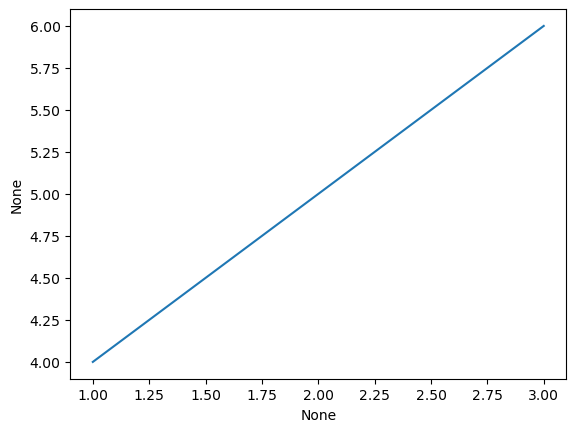

In [10]:
class BasicLightning(L.LightningModule):
    def __init__(self):
        super().__init__()
        self.w00 = nn.Parameter(torch.tensor(1.7), requires_grad=False)
        self.w01 = nn.Parameter(torch.tensor(0.8), requires_grad=False)
        self.w10 = nn.Parameter(torch.tensor(0.9), requires_grad=False)
        self.w11 = nn.Parameter(torch.tensor(0.0), requires_grad=True)
        self.final_bias = nn.Parameter(torch.tensor(0.0), requires_grad=True)

        self.learning_rate = 0.01

    def forward(self, x):
        input_to_top_relu = x * self.w00 + self.w01
        top_relu_output = F.relu(input_to_top_relu)
        scaled_top_relu_output = top_relu_output * self.w10
        input_to_final_relu = scaled_top_relu_output + self.w11

        return F.relu(input_to_final_relu)

    def configure_optimizers(self):
        return SGD(self.parameters(), lr=self.learning_rate)

    def training_step(self, batch, batch_idx):
        input_i, label_i = batch
        output_i = self.forward(input_i)
        loss = (output_i - label_i) ** 2

        return loss.mean()

x = torch.tensor([1, 2, 3])
y = torch.tensor([4, 5, 6])

dataset = TensorDataset(x, y)
dataloader = DataLoader(dataset)

model = BasicLightning()
trainer = L.Trainer(max_epochs=34)

tuner = Tuner(trainer)
lr_find_results = tuner.lr_find(
    model, train_dataloaders = dataloader, min_lr = 0.001,
    max_lr = 1.0, early_stop_threshold = None
)

new_lr = lr_find_results.suggestion()
model.learning_rate = new_lr

trainer.fit(model, train_dataloaders=dataloader)

sns.lineplot(x=x, y=y.detach())
plt.show()


In [ ]:
class LSTMbyHand(L.LightningModule):
    def __init__()
    mean = torch.tesor(0.)
    std = torch.tensor(1.)

    self.wlr1 = nn.Parameter()